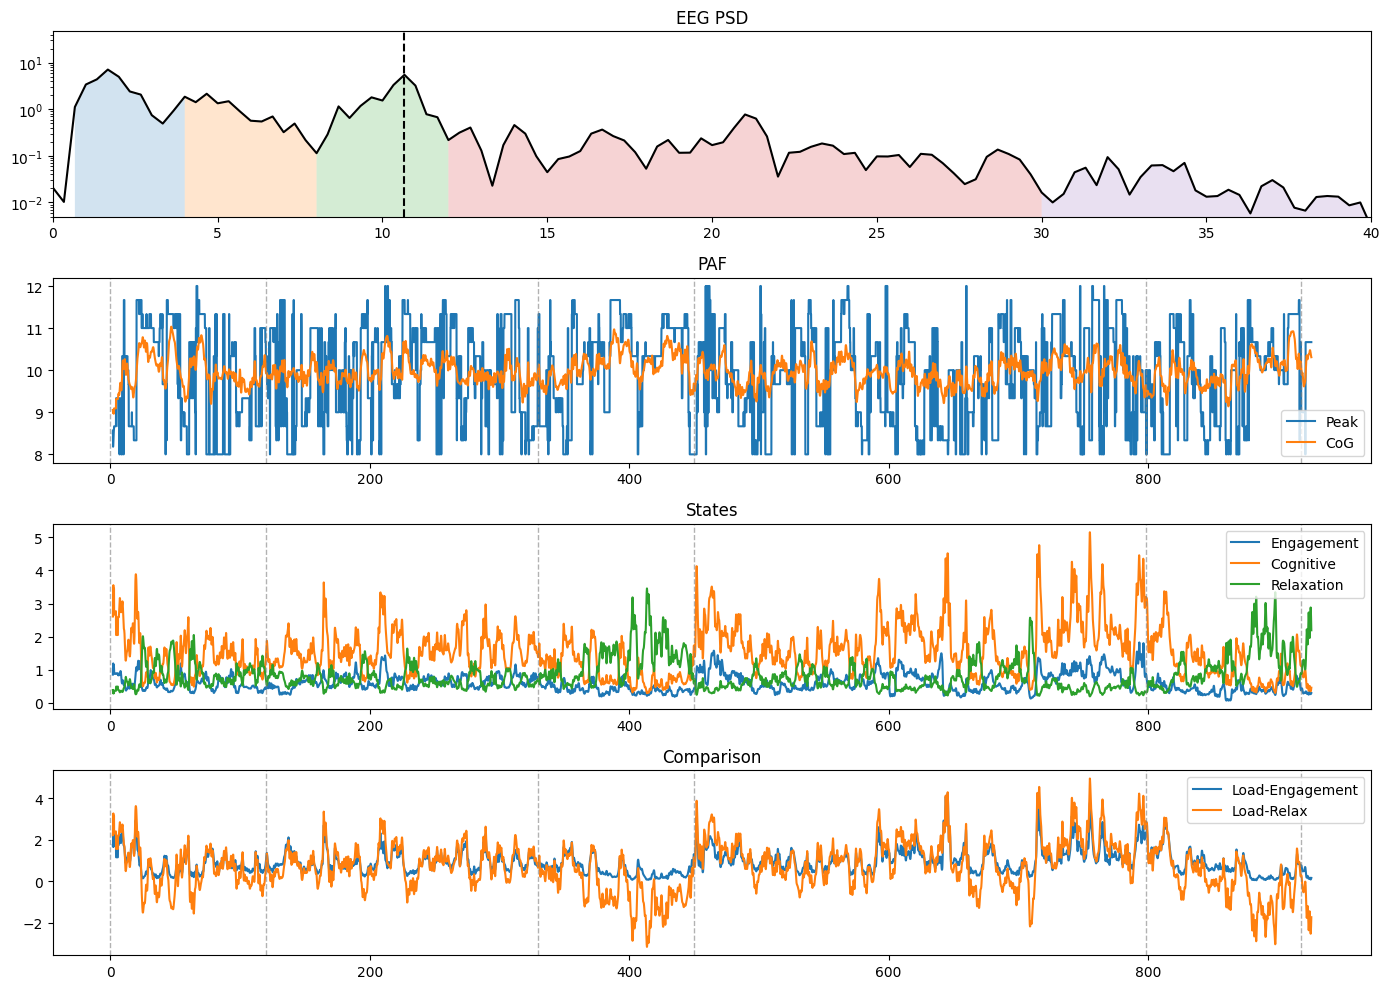

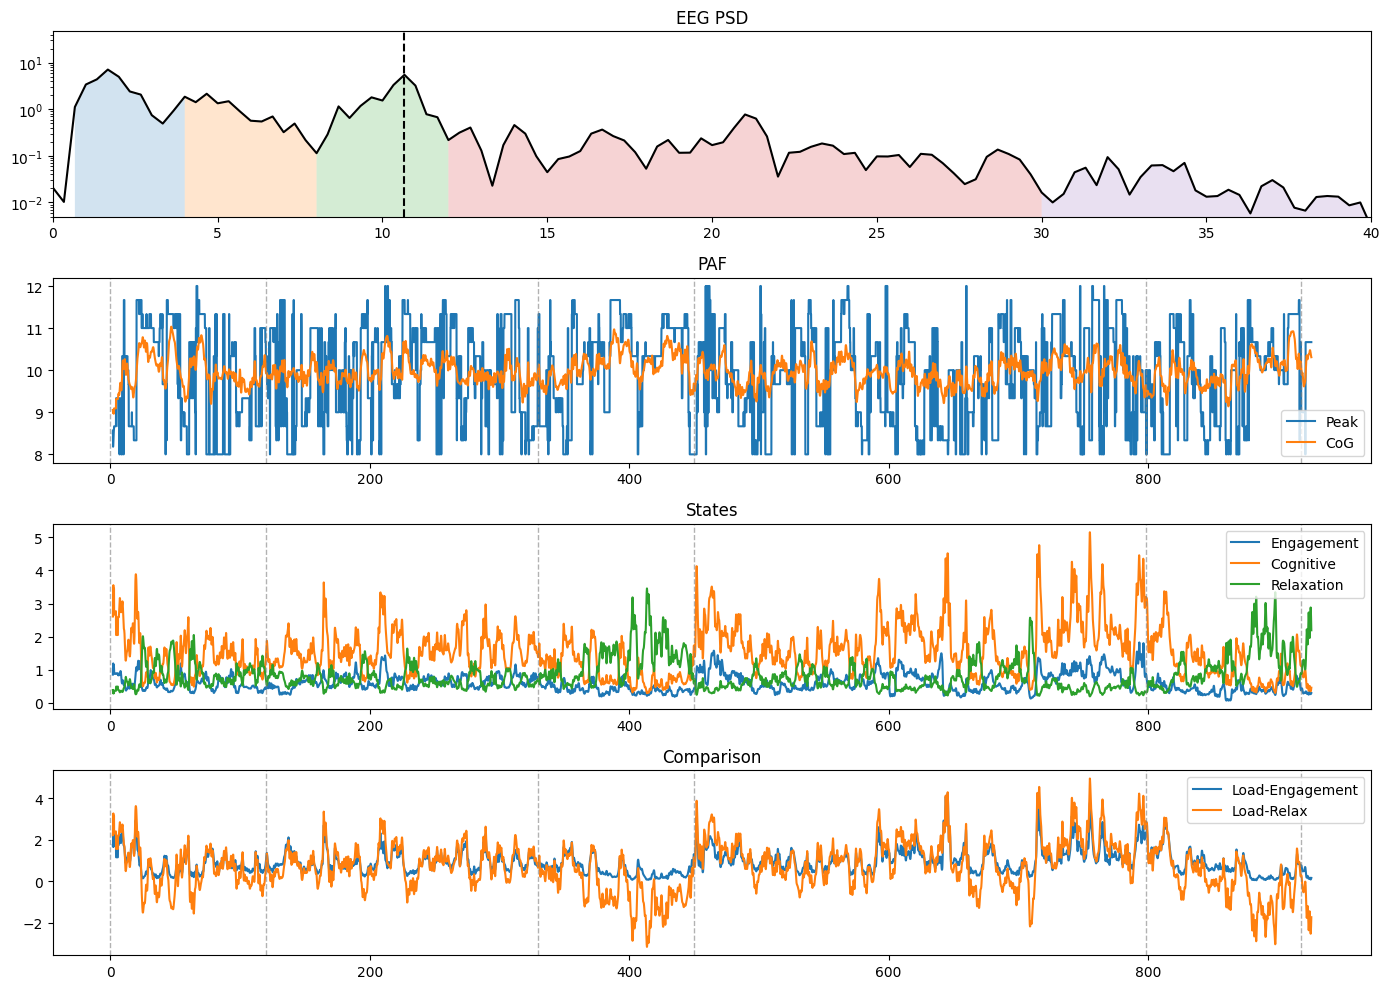

In [1]:
import asyncio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
from scipy import signal
from scipy.signal import welch
from scipy.integrate import trapezoid
from IPython.display import display

# =========================
# CONFIG
# =========================
fs = 250
WINDOW_SECONDS = 6
BUFFER_SIZE = fs * WINDOW_SECONDS

ALPHA_BAND = (8, 12)
NPERSEG_SEC = WINDOW_SECONDS // 2

CSV_FILE = "livedata_test.csv"
CHUNK_SIZE = 25
PLAYBACK_SPEED = 1.0

UPDATE_SECONDS = 0.05

Timestamps = {
    "rest1": (0, 120),
    "game1": (120, 330),
    "rest2": (330, 450),
    "game2": (450, 798),
    "rest3": (798, 918),
}

EVENT_TIMES = [0] + [end for _, (start, end) in Timestamps.items()]

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}

# =========================
# FILTERS
# =========================
b_notch, a_notch = signal.iirnotch(50, Q=30, fs=fs)
sos_bp = signal.butter(N=4, Wn=[1, 40], btype="bandpass", fs=fs, output="sos")

# =========================
# BUFFER
# =========================
class LiveData:
    def __init__(self):
        self.timestamps = deque(maxlen=BUFFER_SIZE)
        self.ch1 = deque(maxlen=BUFFER_SIZE)
        self.is_running = True

live_buffer = LiveData()

# =========================
# STATE
# =========================
paf_times = []
peak_pafs = []
cog_pafs = []

eng_times = []
eng_vals = []
cog_vals = []
relax_vals = []

cmp_eng = []
cmp_relax = []

start_time = None

# =========================
# EVENT LINES
# =========================
def add_event_lines(ax):
    for t in EVENT_TIMES:
        ax.axvline(t, color="gray", linestyle="--", linewidth=1, alpha=0.6)

# =========================
# HANDLER
# =========================
def handle_live_data(event):
    msg = event.get("message", {})
    raw = msg.get("raw_eeg", [])

    for sample in raw:
        live_buffer.ch1.append(sample.get("ch1", 0.0))
        live_buffer.timestamps.append(sample.get("timestamp", 0.0))

# =========================
# FILTERING
# =========================
def apply_window_filters(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 50:
        return x

    x = signal.filtfilt(b_notch, a_notch, x)
    x = signal.sosfiltfilt(sos_bp, x)
    return x - np.mean(x)

# =========================
# PSD
# =========================
def compute_psd(sig):
    nperseg = min(int(NPERSEG_SEC * fs), len(sig))
    if nperseg < fs * 2:
        return None, None

    return welch(
        sig,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window="hann",
        scaling="density"
    )

# =========================
# PAF
# =========================
def compute_paf(freqs, psd):
    mask = (freqs >= ALPHA_BAND[0]) & (freqs <= ALPHA_BAND[1])
    f = freqs[mask]
    p = psd[mask]

    if len(f) == 0 or np.sum(p) == 0:
        return np.nan, np.nan

    return f[np.argmax(p)], np.sum(f * p) / np.sum(p)

# =========================
# FEATURES
# =========================
def compute_features(freqs, psd):
    def bp(band):
        idx = (freqs >= band[0]) & (freqs <= band[1])
        return trapezoid(psd[idx], freqs[idx]) if np.any(idx) else 0.0

    delta = bp(bands["delta"])
    theta = bp(bands["theta"])
    alpha = bp(bands["alpha"])
    beta  = bp(bands["beta"])

    eps = 1e-8

    return {
        "engagement": beta / (alpha + theta + eps),     # Aufmerksamkeit
        "cognitive": beta / (alpha + eps),              # Wie hart arbeitet das Gehirn
        "relaxation": alpha / (beta + eps)              # Wie entspannt ist die Person
    }

# =========================
# LIVE PLOT
# =========================
async def live_plot_task():
    global start_time

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10))
    display_handle = display(fig, display_id=True)

    window_samples = BUFFER_SIZE

    while live_buffer.is_running:

        if len(live_buffer.ch1) >= fs * 2:

            data = np.array(live_buffer.ch1)[-window_samples:]
            filtered = apply_window_filters(data)

            freqs, psd = compute_psd(filtered)
            if freqs is None:
                await asyncio.sleep(UPDATE_SECONDS)
                continue

            peak_paf, cog_paf = compute_paf(freqs, psd)
            f = compute_features(freqs, psd)

            # =========================
            # TIME (FIXED)
            # =========================
            if len(live_buffer.timestamps) > 0:
                if start_time is None:
                    start_time = live_buffer.timestamps[0]
                current_t = live_buffer.timestamps[-1] - start_time
            else:
                current_t = 0

            # =========================
            # STORE
            # =========================
            paf_times.append(current_t)
            peak_pafs.append(peak_paf)
            cog_pafs.append(cog_paf)

            eng_times.append(current_t)
            eng_vals.append(f["engagement"])
            cog_vals.append(f["cognitive"])
            relax_vals.append(f["relaxation"])

            cmp_eng.append(f["cognitive"] - f["engagement"])
            cmp_relax.append(f["cognitive"] - f["relaxation"])

            # =========================
            # PLOT 1
            # =========================
            ax1.clear()
            ax1.semilogy(freqs, psd, color="black")

            for name, (low, high) in bands.items():
                idx = (freqs >= low) & (freqs <= high)
                ax1.fill_between(freqs[idx], psd[idx], alpha=0.2)

            if not np.isnan(peak_paf):
                ax1.axvline(peak_paf, linestyle="--", color="black")

            ax1.set_title("EEG PSD")
            ax1.set_xlim(0, 40)
            ax1.set_ylim(bottom=0.005)
            # =========================
            # PLOT 2
            # =========================
            ax2.clear()
            ax2.plot(paf_times, peak_pafs, label="Peak")
            ax2.plot(paf_times, cog_pafs, label="CoG")
            ax2.set_title("PAF")
            add_event_lines(ax2)
            ax2.legend()

            # =========================
            # PLOT 3
            # =========================
            ax3.clear()
            ax3.plot(eng_times, eng_vals, label="Engagement")
            ax3.plot(eng_times, cog_vals, label="Cognitive")
            ax3.plot(eng_times, relax_vals, label="Relaxation")
            ax3.set_title("States")
            add_event_lines(ax3)
            ax3.legend()

            # =========================
            # PLOT 4
            # =========================
            ax4.clear()
            ax4.plot(eng_times, cmp_eng, label="Load-Engagement")
            ax4.plot(eng_times, cmp_relax, label="Load-Relax")
            ax4.set_title("Comparison")
            add_event_lines(ax4)
            ax4.legend()

            fig.tight_layout()
            display_handle.update(fig)

        await asyncio.sleep(UPDATE_SECONDS)

# =========================
# REPLAY
# =========================
async def replay_csv_chunked(filepath, chunk_size=25, speed=1.0):
    df = pd.read_csv(filepath)

    t = df["timestamp"].values
    x = df["ch1"].values

    start = t[0]

    for i in range(0, len(df), chunk_size):

        chunk = [{
            "timestamp": t[j] - start,
            "ch1": x[j]
        } for j in range(i, min(i + chunk_size, len(df)))]

        handle_live_data({"message": {"raw_eeg": chunk}})

        if i + chunk_size < len(df):
            dt = (t[i + chunk_size] - t[i]) / speed
            await asyncio.sleep(max(dt, 0))

# =========================
# MAIN
# =========================
async def main():
    task = asyncio.create_task(live_plot_task())
    try:
        await replay_csv_chunked(CSV_FILE, CHUNK_SIZE, PLAYBACK_SPEED)
    finally:
        live_buffer.is_running = False
        await task

await main()